# *MICE for CATS* Replication Code
This python notebook replicates the methods in the *MICE for Cats* paper but modifies the code to fit in the application of Abstain/Clarify/Answer scenario.

## 0.&nbsp;Setup

In [1]:
import torch
import pandas as pd
import os
from datasets import load_from_disk
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import joblib

In [ ]:
# Papermill parameters — override via `-p NAME VALUE`.
BUNDLE_DIR = "eval-2.5k"  # default points at precomputed bundle; override with the dir produced by finalize_results.sh

In [3]:
# env setup
from pathlib import Path
import os

BASE_PATH = Path.cwd().parent
FINALIZER_PATH = f"{BASE_PATH}/original_nb_data/MICE_Output/{BUNDLE_DIR}"

layers_full_path  = os.path.join(FINALIZER_PATH, "layers_full.csv")
summary_full_path = os.path.join(FINALIZER_PATH, "summary_full.csv")

print(f"Reading bundle from: {FINALIZER_PATH}")


In [4]:
layers_full = pd.read_csv(layers_full_path)
summary_full = pd.read_csv(summary_full_path)

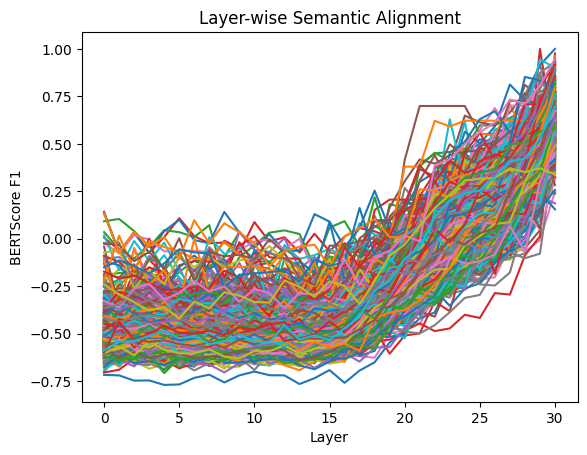

In [5]:
plt.figure()

for qid in layers_full["question_id"].unique():
    subset = layers_full[layers_full["question_id"] == qid]
    plt.plot(subset["layer"], subset["f1"], label=f"QID {qid}")

plt.xlabel("Layer")
plt.ylabel("BERTScore F1")
plt.title("Layer-wise Semantic Alignment")
#plt.legend()
plt.show()

## 1.&nbsp;Classifiers

In [6]:
layer_pivot = (
    layers_full.pivot_table(index="question_id", columns="layer", values="f1")
    .sort_index(axis=1)
    .reset_index()
)
layer_pivot.columns = ["question_id"] + [f"f1_layer_{c}" for c in layer_pivot.columns[1:]]

df = summary_full.merge(layer_pivot, on="question_id")

In [7]:
bundle_path = os.path.join(FINALIZER_PATH, "data_bundle.joblib")

# Load the dictionary
data = joblib.load(bundle_path)

# Unpack the arrays
X_train, y_train, type_train, ptype_train = data['train']
X_val, y_val, type_val, ptype_val = data['val']
X_test, y_test, type_test, ptype_test = data['test']
feature_cols = data['feature_names']
layer_cols = [c for c in feature_cols if c.startswith("f1_layer_")]

print("Arrays loaded successfully.")
print(f"X_train shape: {X_train.shape}")

Arrays loaded successfully.
X_train shape: (600, 32)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

conf_idx = feature_cols.index("normalized_log_confidence")

# Normalise raw confidence to [0,1]
raw_conf = X_test[:, conf_idx]
raw_conf_norm = (raw_conf - raw_conf.min()) / (raw_conf.max() - raw_conf.min() + 1e-10)

# MICE Logistic Regression (L2, C=0.5)
mice_lr = LogisticRegression(C=0.5, max_iter=1000, random_state=42)
mice_lr.fit(X_train_s, y_train)

# MICE Random Forest (paper: 1000 trees, max_depth=20, max_features=10)
mice_rf = RandomForestClassifier(
    n_estimators=1000, max_depth=20, max_features=10,
    random_state=42, n_jobs=-1)
mice_rf.fit(X_train, y_train)

# Predicted probabilities P(correct) - training set
p_hat_rf_train  = mice_rf.predict_proba(X_train)[:, 1]

# Predicted probabilities P(correct) - validation set
p_hat_rf_val  = mice_rf.predict_proba(X_val)[:, 1]

# Predicted probabilities P(correct) - test set
p_hat_raw = raw_conf_norm
p_hat_lr  = mice_lr.predict_proba(X_test_s)[:, 1]
p_hat_rf  = mice_rf.predict_proba(X_test)[:, 1]

print("")
print("--- Classification Report — MICE LR ---")
print(classification_report(y_test, mice_lr.predict(X_test_s), target_names=["mismatch","match"]))
print("--- Classification Report — MICE RF ---")
print(classification_report(y_test, mice_rf.predict(X_test), target_names=["mismatch","match"]))


Train: 600  Val: 200  Test: 200

--- Classification Report — MICE LR ---
              precision    recall  f1-score   support

    mismatch       0.68      0.87      0.76       126
       match       0.57      0.31      0.40        74

    accuracy                           0.66       200
   macro avg       0.63      0.59      0.58       200
weighted avg       0.64      0.66      0.63       200

--- Classification Report — MICE RF ---
              precision    recall  f1-score   support

    mismatch       0.73      0.88      0.80       126
       match       0.68      0.43      0.53        74

    accuracy                           0.71       200
   macro avg       0.70      0.66      0.66       200
weighted avg       0.71      0.71      0.70       200



## 2.&nbsp;Evaluation

### a.&nbsp;smECE

#### i.&nbsp;Implementation

In [9]:
# smECE implementation

def silverman_bandwidth(p_hat: np.ndarray) -> float:
    n   = len(p_hat)
    std = np.std(p_hat, ddof=1)
    iqr = np.percentile(p_hat, 75) - np.percentile(p_hat, 25)
    s   = min(std, iqr / 1.34)
    return 0.9 * s * n ** (-0.2)

def nw_accuracy(p_eval, p_hat, y_true, bw):
    """Nadaraya–Watson local accuracy with reflected Gaussian kernel."""
    def gk(u): return np.exp(-0.5 * (u / bw) ** 2)
    k = gk(p_hat - p_eval) + gk(p_hat + p_eval) + gk(p_hat - (2 - p_eval))
    d = k.sum()
    return (k * y_true).sum() / d if d > 1e-12 else p_eval

def compute_smece(p_hat: np.ndarray, y_true: np.ndarray, n_eval: int = 500) -> float:
    bw        = silverman_bandwidth(p_hat)
    grid      = np.linspace(0, 1, n_eval)
    acc_curve = np.array([nw_accuracy(g, p_hat, y_true, bw) for g in grid])
    # Density weights via KDE
    def gk(u): return np.exp(-0.5 * (u / bw) ** 2)
    density = np.array([
        (gk(p_hat - g) + gk(p_hat + g) + gk(p_hat - (2 - g))).sum()
        for g in grid])
    density /= density.sum()
    return float(np.sum(density * np.abs(acc_curve - grid)))

smece_raw = compute_smece(p_hat_raw, y_test)
smece_lr  = compute_smece(p_hat_lr,  y_test)
smece_rf  = compute_smece(p_hat_rf,  y_test)

print(f"smECE  Raw Confidence : {smece_raw:.4f}")
print(f"smECE  MICE LR        : {smece_lr:.4f}")
print(f"smECE  MICE RF        : {smece_rf:.4f}")

smECE  Raw Confidence : 0.2806
smECE  MICE LR        : 0.0325
smECE  MICE RF        : 0.0212


#### ii.&nbsp;Plots

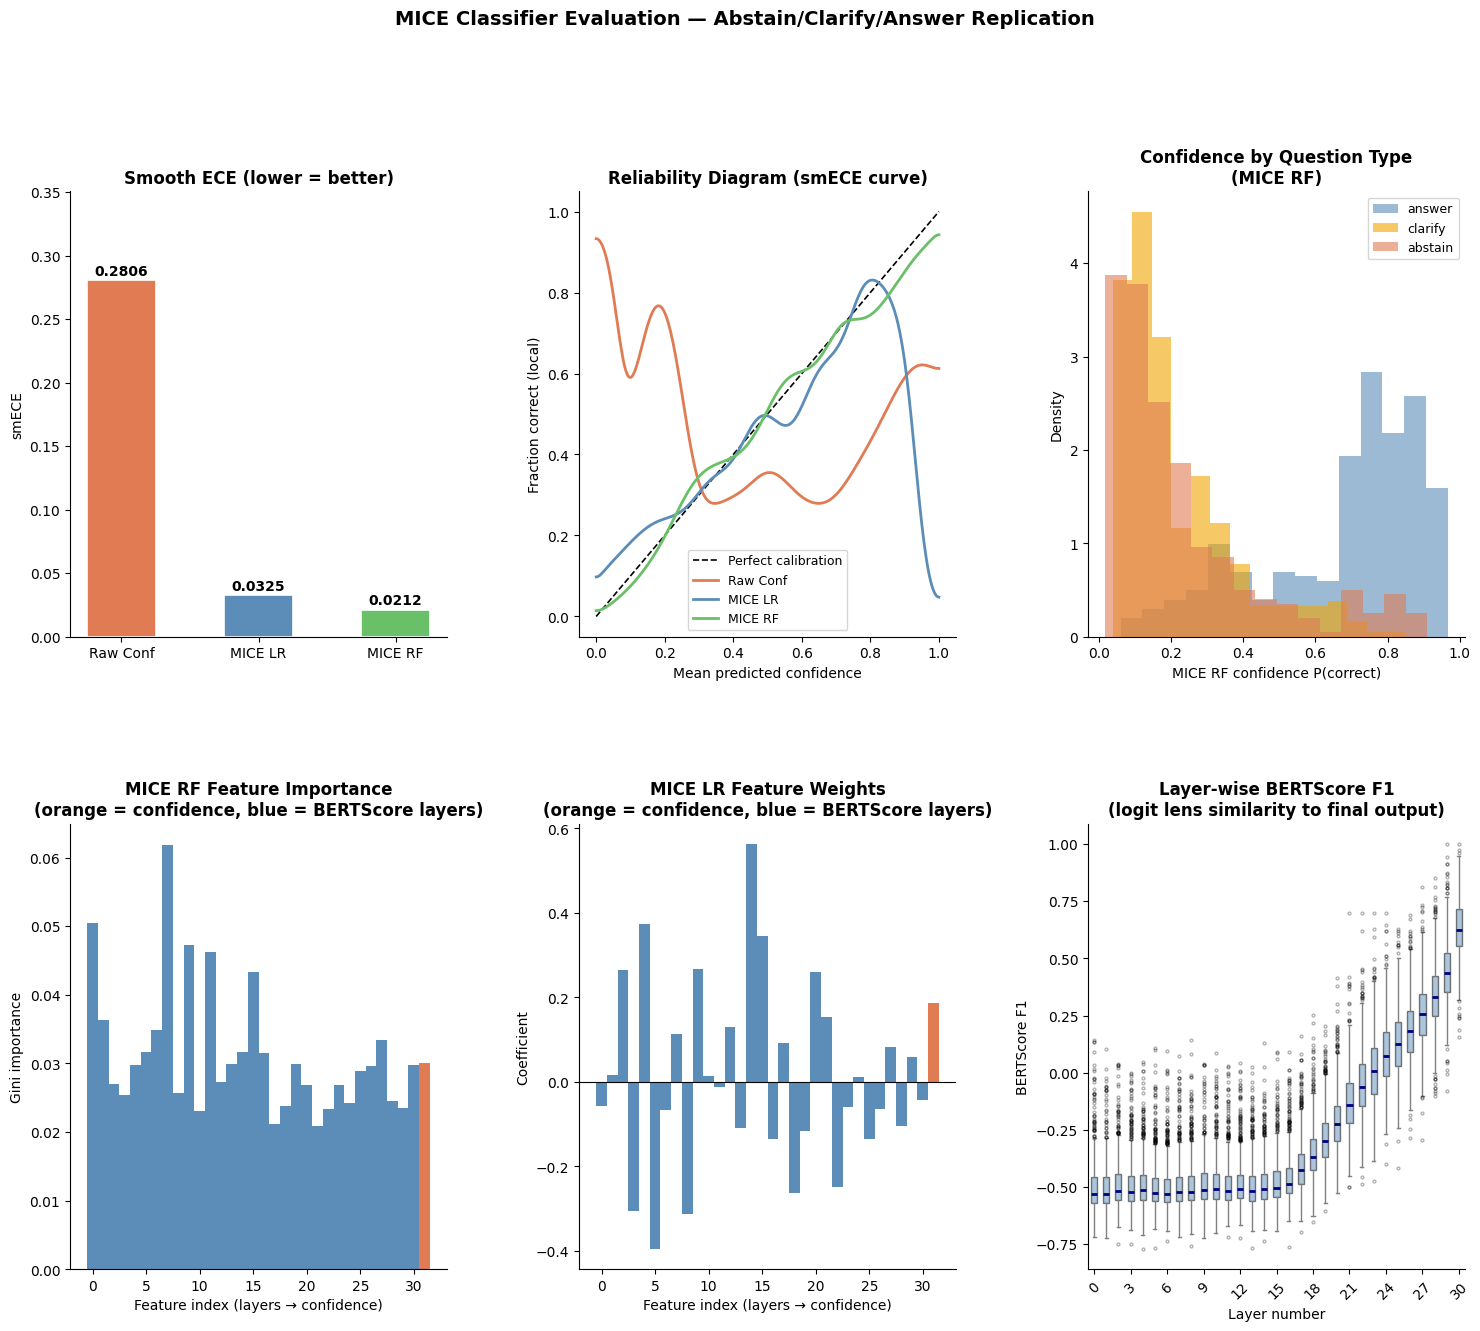

In [10]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# 1. smECE bar chart
ax1 = fig.add_subplot(gs[0, 0])
labels  = ["Raw Conf", "MICE LR", "MICE RF"]
values  = [smece_raw, smece_lr, smece_rf]
colors  = ["#e07b54", "#5b8db8", "#6abf69"]
bars = ax1.bar(labels, values, color=colors, width=0.5, edgecolor="white", linewidth=1.2)
for b, v in zip(bars, values):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.4f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.set_title("Smooth ECE (lower = better)", fontweight="bold")
ax1.set_ylabel("smECE")
ax1.set_ylim(0, max(values) * 1.25)
ax1.spines[["top","right"]].set_visible(False)

# 2. Reliability diagram (calibration curve)
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot([0,1],[0,1], "k--", lw=1.2, label="Perfect calibration")
for p_hat, label, color in [
        (p_hat_raw, "Raw Conf",  "#e07b54"),
        (p_hat_lr,  "MICE LR",   "#5b8db8"),
        (p_hat_rf,  "MICE RF",   "#6abf69")]:
    bw   = silverman_bandwidth(p_hat)
    grid = np.linspace(0, 1, 300)
    acc  = np.array([nw_accuracy(g, p_hat, y_test, bw) for g in grid])
    ax2.plot(grid, acc, label=label, color=color, lw=2)
ax2.set_xlabel("Mean predicted confidence")
ax2.set_ylabel("Fraction correct (local)")
ax2.set_title("Reliability Diagram (smECE curve)", fontweight="bold")
ax2.legend(fontsize=9)
ax2.spines[["top","right"]].set_visible(False)

# 3. Confidence distribution by true type
ax3 = fig.add_subplot(gs[0, 2])
# Run RF over the full df so we can mask by type (p_hat_rf is test-set only)
X_full       = df[feature_cols].values.astype(np.float32)
all_rf_probs = mice_rf.predict_proba(X_full)[:, 1]

for qtype, color in [("answer","#5b8db8"),("clarify","#f0a500"),("abstain","#e07b54")]:
    mask = df["type"].values == qtype
    ax3.hist(all_rf_probs[mask], bins=15, alpha=0.6, color=color, label=qtype, density=True)
ax3.set_xlabel("MICE RF confidence P(correct)")
ax3.set_ylabel("Density")
ax3.set_title("Confidence by Question Type\n(MICE RF)", fontweight="bold")
ax3.legend(fontsize=9)
ax3.spines[["top","right"]].set_visible(False)

# 4. Feature importance (MICE RF Gini)
ax4 = fig.add_subplot(gs[1, 0])
importances = mice_rf.feature_importances_
ax4.bar(range(len(importances)), importances,
        color=["#e07b54" if c == "normalized_log_confidence" else "#5b8db8"
               for c in feature_cols],
        width=1.0)
ax4.set_xlabel("Feature index (layers → confidence)")
ax4.set_ylabel("Gini importance")
ax4.set_title("MICE RF Feature Importance\n(orange = confidence, blue = BERTScore layers)",
              fontweight="bold")
ax4.spines[["top","right"]].set_visible(False)

# 5. LR feature weights
ax5 = fig.add_subplot(gs[1, 1])
weights = mice_lr.coef_[0]
ax5.bar(range(len(weights)), weights,
        color=["#e07b54" if c == "normalized_log_confidence" else "#5b8db8"
               for c in feature_cols],
        width=1.0)
ax5.axhline(0, color="black", lw=0.8)
ax5.set_xlabel("Feature index (layers → confidence)")
ax5.set_ylabel("Coefficient")
ax5.set_title("MICE LR Feature Weights\n(orange = confidence, blue = BERTScore layers)",
              fontweight="bold")
ax5.spines[["top","right"]].set_visible(False)

# 6. BERTScore F1 across layers (box plot)
ax6 = fig.add_subplot(gs[1, 2])
layer_data = [df[c].values for c in layer_cols]
bp = ax6.boxplot(layer_data, patch_artist=True,
                 boxprops=dict(facecolor="#5b8db8", alpha=0.5),
                 medianprops=dict(color="navy", lw=2),
                 whiskerprops=dict(color="grey"),
                 capprops=dict(color="grey"),
                 flierprops=dict(marker="o", markersize=2, alpha=0.3))
ax6.set_xlabel("Layer number")
ax6.set_ylabel("BERTScore F1")
ax6.set_title("Layer-wise BERTScore F1\n(logit lens similarity to final output)",
              fontweight="bold")
ax6.set_xticks(range(1, len(layer_cols)+1, max(1, len(layer_cols)//8)))
ax6.set_xticklabels(range(0, len(layer_cols), max(1, len(layer_cols)//8)), rotation=45)
ax6.spines[["top","right"]].set_visible(False)

plt.suptitle("MICE Classifier Evaluation — Abstain/Clarify/Answer Replication",
             fontsize=14, fontweight="bold", y=1.01)
plt.show()

### b.&nbsp;Utility

In [11]:
from sklearn.metrics import roc_auc_score, average_precision_score

# -----------------------------
# Helpers
# -----------------------------
def minmax_fit(x):
    x = np.asarray(x, dtype=float)
    return float(np.min(x)), float(np.max(x))

def minmax_transform(x, lo, hi):
    x = np.asarray(x, dtype=float)
    return (x - lo) / (hi - lo + 1e-12)

def safe_roc_auc(y_true, scores):
    scores = np.asarray(scores, dtype=float)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, scores))

def safe_pr_auc(y_true, scores):
    scores = np.asarray(scores, dtype=float)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, scores))

# -----------------------------
# Confidence scores for train/val/test
# -----------------------------
raw_idx = feature_cols.index("normalized_log_confidence")

raw_train = X_train[:, raw_idx]
raw_val   = X_val[:, raw_idx]
raw_test  = X_test[:, raw_idx]

# -----------------------------
# AUC summary
# -----------------------------
auc_rows = []
for name, y_split, p_split in [
    ("Raw confidence", y_test, p_hat_raw),
    ("MICE LR",        y_test, p_hat_lr),
    ("MICE RF",        y_test, p_hat_rf),
]:
    auc_rows.append({
        "model": name,
        "ROC_AUC": safe_roc_auc(y_split, p_split),
        "PR_AUC": safe_pr_auc(y_split, p_split),
    })

auc_df = pd.DataFrame(auc_rows)
print("=== AUC on test split ===")
display(auc_df)

# -----------------------------
# Utility / risk profiles
# -----------------------------
# Interpretation:
#   answer  = trust the LLM's normal response
#   clarify = force a clarification question
#   abstain = force refusal / no answer
#
# Utilities are encoded as:
#   U(action | correct) and U(action | incorrect)
# so expected utility is p*U_correct + (1-p)*U_incorrect

RISK_PROFILES = {
    "low": {
        "answer_correct": 1.0,
        "answer_incorrect": -0.5,
        "clarify_correct": 0.10,
        "clarify_incorrect": -0.20,
        "abstain_correct": -0.30,
        "abstain_incorrect": -0.10,
    },
    "medium": {
        "answer_correct": 1.0,
        "answer_incorrect": -1.0,
        "clarify_correct": 0.10,
        "clarify_incorrect": -0.20,
        "abstain_correct": -0.30,
        "abstain_incorrect": -0.10,
    },
    "high": {
        "answer_correct": 1.0,
        "answer_incorrect": -9.0,
        "clarify_correct": 0.10,
        "clarify_incorrect": -0.20,
        "abstain_correct": -0.30,
        "abstain_incorrect": -0.10,
    },
}

def expected_utilities(p, u):
    """Return expected utility for each action at confidence p."""
    eu_answer = p * u["answer_correct"] + (1 - p) * u["answer_incorrect"]
    eu_clarify = p * u["clarify_correct"] + (1 - p) * u["clarify_incorrect"]
    eu_abstain = p * u["abstain_correct"] + (1 - p) * u["abstain_incorrect"]
    return {"answer": eu_answer, "clarify": eu_clarify, "abstain": eu_abstain}

def choose_action(p, u):
    eus = expected_utilities(p, u)
    return max(eus.items(), key=lambda kv: kv[1])[0]

def infer_thresholds(u, grid_size=10001):
    """
    Approximate the low/high thresholds implied by the utility table.
    Returns:
      t_low  = last confidence where abstain is best before clarify takes over
      t_high = first confidence where answer becomes best
    """
    grid = np.linspace(0.0, 1.0, grid_size)
    acts = np.array([choose_action(float(p), u) for p in grid])

    abstain_idx = np.where(acts == "abstain")[0]
    answer_idx  = np.where(acts == "answer")[0]

    t_low = float(grid[abstain_idx[-1]]) if len(abstain_idx) else 0.0
    t_high = float(grid[answer_idx[0]]) if len(answer_idx) else 1.0

    return t_low, t_high

def evaluate_policy(y_true, p_scores, u):
    p_scores = np.asarray(p_scores, dtype=float)

    actions = np.array([choose_action(float(p), u) for p in p_scores])

    realized = np.zeros_like(p_scores, dtype=float)
    realized[(actions == "answer") & (y_true == 1)] = u["answer_correct"]
    realized[(actions == "answer") & (y_true == 0)] = u["answer_incorrect"]
    realized[(actions == "clarify") & (y_true == 1)] = u["clarify_correct"]
    realized[(actions == "clarify") & (y_true == 0)] = u["clarify_incorrect"]
    realized[(actions == "abstain") & (y_true == 1)]  = u["abstain_correct"]
    realized[(actions == "abstain") & (y_true == 0)]  = u["abstain_incorrect"]

    t_low, t_high = infer_thresholds(u)

    return {
        "avg_utility": float(np.mean(realized)),
        "answer_rate": float(np.mean(actions == "answer")),
        "clarify_rate": float(np.mean(actions == "clarify")),
        "abstain_rate": float(np.mean(actions == "abstain")),
        "t_low": t_low,
        "t_high": t_high,
    }

# -----------------------------
# Utility summary on test split
# -----------------------------
model_scores = {
    "Raw confidence": p_hat_raw,
    "MICE LR": p_hat_lr,
    "MICE RF": p_hat_rf,
}

rows = []
for risk_name, u in RISK_PROFILES.items():
    t_low, t_high = infer_thresholds(u)
    for model_name, scores in model_scores.items():
        out = evaluate_policy(y_test, scores, u)
        rows.append({
            "risk": risk_name,
            "model": model_name,
            "ROC_AUC": safe_roc_auc(y_test, scores),
            "PR_AUC": safe_pr_auc(y_test, scores),
            "avg_utility": out["avg_utility"],
            "answer_rate": out["answer_rate"],
            "clarify_rate": out["clarify_rate"],
            "abstain_rate": out["abstain_rate"],
            "t_low": t_low,
            "t_high": t_high,
        })

results_df = pd.DataFrame(rows).sort_values(["risk", "model"]).reset_index(drop=True)

print("=== Utility summary on test split ===")
display(results_df)

print("=== Average utility (higher is better) ===")
display(results_df.pivot(index="model", columns="risk", values="avg_utility"))

=== AUC on test split ===


,model,ROC_AUC,PR_AUC
0,Raw confidence,0.540648,0.461374
1,MICE LR,0.671064,0.543471
2,MICE RF,0.750536,0.633356


=== Utility summary on test split ===


,risk,model,ROC_AUC,PR_AUC,avg_utility,answer_rate,clarify_rate,abstain_rate,t_low,t_high
0,high,MICE LR,0.671064,0.543471,-0.1345,0.005,0.860,0.135,0.1999,0.9073
1,high,MICE RF,0.750536,0.633356,-0.0760,0.000,0.770,0.230,0.1999,0.9073
2,high,Raw confidence,0.540648,0.461374,-0.1995,0.045,0.935,0.020,0.1999,0.9073
3,low,MICE LR,0.671064,0.543471,0.0625,0.710,0.155,0.135,0.1999,0.2500
4,low,MICE RF,0.750536,0.633356,0.1190,0.670,0.100,0.230,0.1999,0.2500
5,low,Raw confidence,0.540648,0.461374,0.0240,0.965,0.015,0.020,0.1999,0.2500
6,medium,MICE LR,0.671064,0.543471,-0.0565,0.255,0.610,0.135,0.1999,0.4706
7,medium,MICE RF,0.750536,0.633356,-0.0020,0.290,0.480,0.230,0.1999,0.4706
8,medium,Raw confidence,0.540648,0.461374,-0.2295,0.785,0.195,0.020,0.1999,0.4706


=== Average utility (higher is better) ===


risk,high,low,medium
model,,,
MICE LR,-0.1345,0.0625,-0.0565
MICE RF,-0.0760,0.1190,-0.0020
Raw confidence,-0.1995,0.0240,-0.2295


### c.&nbsp;Analysis on Accuracy (Random Forest)

#### i.&nbsp;Implementation

In [12]:
def compute_mbr_thresholds(y_true, y_probs, types, loss_matrix=None, n_thresholds=200):
    if loss_matrix is None:
        # row (penalty for each type given what actual type is): [match,  clarify-Miss  abstain-miss]
        loss_matrix = np.array([
            [0, 1, 1],   # continue
            [1, 0, 1],   # clarify
            [1, 1, 0],   # abstain
        ], dtype=float)

    y_true  = np.asarray(y_true)
    y_probs = np.asarray(y_probs)
    types   = np.asarray(types)

    # 0=match, 1=clarify-miss, 2=abstain-miss
    true_classes = np.where(
        y_true == 1, 0,
        np.where(types == 'clarify', 1, 2)
    )

    candidates = np.linspace(0.01, 0.99, n_thresholds)
    best_risk = np.inf
    best_a, best_b = 0.7, 0.3

    for a in candidates:
        for b in candidates:
            if b >= a:
                continue
            actions = np.where(y_probs > a, 0,
                      np.where(y_probs > b, 1, 2))
            risk = loss_matrix[actions, true_classes].mean()
            if risk < best_risk:
                best_risk = risk
                best_a, best_b = a, b

    return round(best_a, 2), round(best_b, 2)


def compute_accuracy(y_true, y_probs, types, a, b):
    """
    Determine correctness for every sample based on which decision zone it
    falls into, then compute overall accuracy and per-type accuracy.

    Decision zones and their correctness rules:

    Above a  (Answer zone):
        y_true == 1 (any type)         -> correct
        y_true == 0, type == 'answer'  -> correct
        y_true == 0, other types       -> wrong

    Between b and a  (Clarify zone):
        type == 'clarify'              -> correct  (regardless of y_true)
        all other types                -> wrong

    Below b  (Abstain zone):
        type == 'abstain'              -> correct  (regardless of y_true)
        all other types                -> wrong

    Per-type accuracy:

    For each type t in {'answer', 'clarify', 'abstain'}, accuracy is:
        (# samples of type t marked correct) / (# samples of type t)

    A sample's type determines which per-type bucket it belongs to, while
    the correctness rules above determine whether it is a hit or a miss.


    Returns:

    overall_acc : float in [0, 1]
    type_stats  : dict  {type_name: {'acc': float, 'correct': int, 'total': int}}
    correct     : bool array of shape (n,), True where prediction was correct
    """
    y_true = np.asarray(y_true)
    y_probs = np.asarray(y_probs)
    types = np.asarray(types)

    correct = np.zeros(len(y_true), dtype=bool)

    above = y_probs > a
    between = (y_probs > b) & (y_probs <= a)
    below = y_probs <= b

    correct[above & (y_true == 1)] = True
    correct[above & (y_true == 0) & (types == 'answer')]  = True

    correct[between & (types == 'clarify')] = True

    correct[below & (types == 'abstain')] = True

    overall_acc = correct.mean()

    type_stats = {}
    for t in ['answer', 'clarify', 'abstain']:
        mask  = types == t
        total = int(mask.sum())
        n_correct = int(correct[mask].sum())
        type_stats[t] = {
            'acc': n_correct / total if total > 0 else None,
            'correct': n_correct,
            'total': total,
        }

    return overall_acc, type_stats, correct


def plot_accuracy(overall_acc, type_stats, a, b, title="Accuracy by Decision Type"):
    TYPE_COLORS = {
        'answer':  '#2ecc71',   # green - answer
        'clarify': '#e67e22',   # orange - clarify
        'abstain': '#e74c3c',   # red - abstain
        'overall': '#3498db',   # blue - overall bar
    }
    ZONE_LABELS = {
        'answer':  f'Answer  (score > {a:.2f})',
        'clarify': f'Clarify  ({b:.2f} < score ≤ {a:.2f})',
        'abstain': f'Abstain  (score ≤ {b:.2f})',
        'overall': 'Overall',
    }

    keys = ['answer', 'clarify', 'abstain']
    accs = [type_stats[k]['acc'] for k in keys]
    n_correct = [type_stats[k]['correct'] for k in keys]
    n_total = [type_stats[k]['total'] for k in keys]
    colors = [TYPE_COLORS[k] for k in keys]
    row_labels = [ZONE_LABELS[k] for k in keys]

    keys.append('overall')
    accs.append(overall_acc)
    total_correct = sum(n_correct)
    total_n = sum(n_total)
    n_correct.append(total_correct)
    n_total.append(total_n)
    colors.append(TYPE_COLORS['overall'])
    row_labels.append(ZONE_LABELS['overall'])

    fig, ax = plt.subplots(figsize=(10, 5))

    y_pos = range(len(keys))
    bars = ax.barh(
        list(y_pos), accs,
        color=colors, alpha=0.82, edgecolor='white', linewidth=1.2, height=0.55,
    )

    ax.axhline(y=len(keys) - 1 - 0.45, color='#999999', linewidth=1.0, linestyle='--')

    for i, (bar, acc, nc, nt) in enumerate(zip(bars, accs, n_correct, n_total)):
        if acc is None:
            ax.text(0.02, bar.get_y() + bar.get_height() / 2,
                    'No samples', va='center', ha='left', fontsize=10, color='grey')
            continue

        x_txt = acc - 0.02 if acc > 0.15 else acc + 0.01
        ha_txt = 'right' if acc > 0.15 else 'left'
        ax.text(
            x_txt, bar.get_y() + bar.get_height() / 2,
            f'{nc} / {nt}   ({acc * 100:.1f}%)',
            va='center', ha=ha_txt, fontsize=10, fontweight='bold',
            color='white' if acc > 0.15 else colors[i],
        )

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(row_labels, fontsize=11)
    ax.set_xlabel('Accuracy', fontsize=12)
    ax.set_xlim(0, 1.0)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.set_title(title, fontsize=14, pad=12)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()


def plot_confidence_distribution(
    y_true, y_probs, types,
    title="Confidence Scores",
    a=None, b=None,
    loss_matrix=None,
    val_y_true=None, val_y_probs=None, val_types=None,
):
    y_true  = np.asarray(y_true)
    y_probs = np.asarray(y_probs)
    types   = np.asarray(types)

    # threshold resolution with MBR
    mbr_computed  = False
    mbr_used_val  = False

    if a is None or b is None:
        val_available = (
            val_y_true  is not None and
            val_y_probs is not None and
            val_types   is not None
        )

        if val_available:
            mbr_y_true  = np.asarray(val_y_true)
            mbr_y_probs = np.asarray(val_y_probs)
            mbr_types   = np.asarray(val_types)
            mbr_used_val = True
        else:
            # fall back to test set
            mbr_y_true  = y_true
            mbr_y_probs = y_probs
            mbr_types   = types

        mbr_a, mbr_b = compute_mbr_thresholds(
            mbr_y_true, mbr_y_probs, mbr_types, loss_matrix
        )
        mbr_computed = True
        if a is None: a = mbr_a
        if b is None: b = mbr_b

    overall_acc, type_stats, correct = compute_accuracy(y_true, y_probs, types, a, b)

    if not mbr_computed:
        mbr_tag = ""
    else:
        mbr_tag = " [MBR]"

    mask_match = (y_true == 1)
    mask_clarify = (y_true == 0) & (types == 'clarify')
    mask_abstain = (y_true == 0) & (types == 'abstain')

    categories = [
        (y_probs[mask_match], correct[mask_match], 'Match (y=1)', 'green', 0),
        (y_probs[mask_clarify], correct[mask_clarify], 'Mismatch - Clarify', 'orange', 1),
        (y_probs[mask_abstain], correct[mask_abstain], 'Mismatch - Abstain', 'red', 2),
    ]

    plt.figure(figsize=(14, 7))

    plt.axvspan(0, b, color='red', alpha=0.05, zorder=0)
    plt.axvspan(b, a, color='orange', alpha=0.05, zorder=0)
    plt.axvspan(a, 1.12, color='green', alpha=0.05, zorder=0)

    plt.axvline(x=a, color='green', linestyle=':', alpha=0.8,
                label=f'Upper Threshold — Continue if above: {a:.2f}{mbr_tag}')
    plt.axvline(x=b, color='red',   linestyle=':', alpha=0.8,
                label=f'Lower Threshold — Abstain if below: {b:.2f}{mbr_tag}')

    for scores, is_correct, label, color, y_level in categories:
        if len(scores) == 0:
            continue

        jitter = np.random.normal(y_level, 0.08, size=len(scores))
        plt.scatter(scores[is_correct],  jitter[is_correct],
                    alpha=0.5, s=20, c=color, marker='o', zorder=3)
        plt.scatter(scores[~is_correct], jitter[~is_correct],
                    alpha=0.6, s=24, c='black', marker='x', zorder=4,
                    label='Incorrect prediction' if y_level == 0 else '')

        vp = plt.violinplot(
            scores, positions=[y_level], vert=False,
            widths=0.5, showmeans=False, showmedians=False, showextrema=False,
        )
        for body in vp['bodies']:
            body.set_facecolor(color)
            body.set_alpha(0.15)

        mu, sigma = np.mean(scores), np.std(scores)
        plt.vlines(mu, y_level - 0.25, y_level + 0.25,
                   color='black', linewidth=3, zorder=5)
        plt.text(1.02, y_level, f'μ={mu:.2f}\nσ={sigma:.2f}',
                 va='center', fontsize=10, fontweight='bold')

    plt.title(f'{title} - Confidence Distribution', fontsize=16, pad=15)
    plt.xlabel("Predicted Confidence Score $P(match)$", fontsize=12)
    plt.yticks([0, 1, 2], ['Matches', 'Clarify (Miss)', 'Abstain (Miss)'])
    plt.ylim(-0.6, 2.6)
    plt.xlim(0, 1.12)
    plt.grid(axis='x', linestyle='--', alpha=0.4)

    handles, labels_list = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels_list, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper right', framealpha=0.9)

    plt.tight_layout()
    plt.show()

    print('')
    plot_accuracy(overall_acc, type_stats, a, b, title=f'{title} - Accuracy')

In [13]:
def plot_baseline_accuracy(y_true, types, title="Baseline Accuracy by Type"):
    # Accuracy derived purely from y_true, with no threshold logic.

    y_true = np.asarray(y_true)
    types  = np.asarray(types)

    correct = (y_true == 1)
    overall_acc = correct.mean()

    type_stats = {}
    for t in ['answer', 'clarify', 'abstain']:
        mask  = types == t
        total = int(mask.sum())
        n_correct = int(correct[mask].sum())
        type_stats[t] = {
            'acc':     n_correct / total if total > 0 else None,
            'correct': n_correct,
            'total':   total,
        }

    _plot_baseline_accuracy(overall_acc, type_stats, title)


def _plot_baseline_accuracy(overall_acc, type_stats, title):
    TYPE_COLORS = {
        'answer':  '#2ecc71',
        'clarify': '#e67e22',
        'abstain': '#e74c3c',
        'overall': '#3498db',
    }
    ROW_LABELS = {
        'answer':  'Answer',
        'clarify': 'Clarify',
        'abstain': 'Abstain',
        'overall': 'Overall',
    }

    keys = ['answer', 'clarify', 'abstain']
    accs = [type_stats[k]['acc'] for k in keys]
    n_correct = [type_stats[k]['correct'] for k in keys]
    n_total = [type_stats[k]['total'] for k in keys]
    colors = [TYPE_COLORS[k] for k in keys]

    keys.append('overall')
    accs.append(overall_acc)
    n_correct.append(sum(n_correct))
    n_total.append(sum(n_total))
    colors.append(TYPE_COLORS['overall'])

    row_labels = [ROW_LABELS[k] for k in keys]

    fig, ax = plt.subplots(figsize=(10, 5))
    y_pos = range(len(keys))

    bars = ax.barh(
        list(y_pos), accs,
        color=colors, alpha=0.82, edgecolor='white', linewidth=1.2, height=0.55,
    )

    ax.axhline(y=len(keys) - 1 - 0.45, color='#999999', linewidth=1.0, linestyle='--')

    for bar, acc, nc, nt in zip(bars, accs, n_correct, n_total):
        if acc is None:
            ax.text(0.02, bar.get_y() + bar.get_height() / 2,
                    'No samples', va='center', ha='left', fontsize=10, color='grey')
            continue

        x_txt  = acc - 0.02 if acc > 0.15 else acc + 0.01
        ha_txt = 'right' if acc > 0.15 else 'left'
        color  = 'white' if acc > 0.15 else bar.get_facecolor()
        ax.text(
            x_txt, bar.get_y() + bar.get_height() / 2,
            f'{nc} / {nt}   ({acc * 100:.1f}%)',
            va='center', ha=ha_txt, fontsize=10, fontweight='bold', color=color,
        )

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(row_labels, fontsize=11)
    ax.set_xlabel('Accuracy  (fraction of y_true == 1)', fontsize=12)
    ax.set_xlim(0, 1.0)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.set_title(title, fontsize=14, pad=12)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

In [14]:
def plot_type_prediction_accuracy(true_types, pred_types,title="Prediction Accuracy by Type"):
    true_types = np.asarray(true_types)
    pred_types = np.asarray(pred_types)

    correct = (pred_types == true_types)
    overall_acc = correct.mean()

    type_stats = {}
    for t in ['answer', 'clarify', 'abstain']:
        mask = true_types == t
        total = int(mask.sum())
        n_correct = int(correct[mask].sum())

        type_stats[t] = {
            'acc': n_correct / total if total > 0 else None,
            'correct': n_correct,
            'total': total,
        }

    _plot_baseline_accuracy(overall_acc, type_stats, title)

#### ii.&nbsp;Plots

##### 1.&nbsp;Baseline Accuracy (Llama 3)

###### a.&nbsp;Training Set

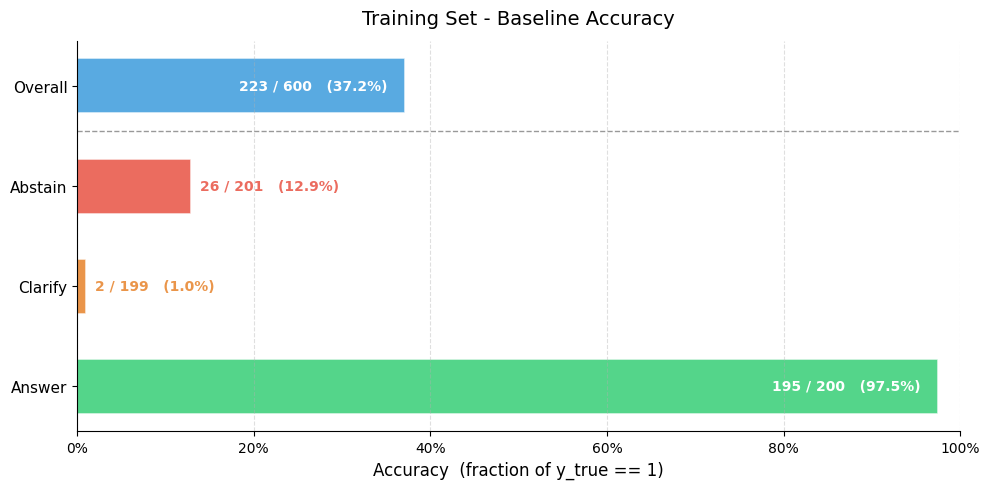

In [15]:
plot_baseline_accuracy(y_train, type_train, title="Training Set - Baseline Accuracy")

###### b.&nbsp;Test Set

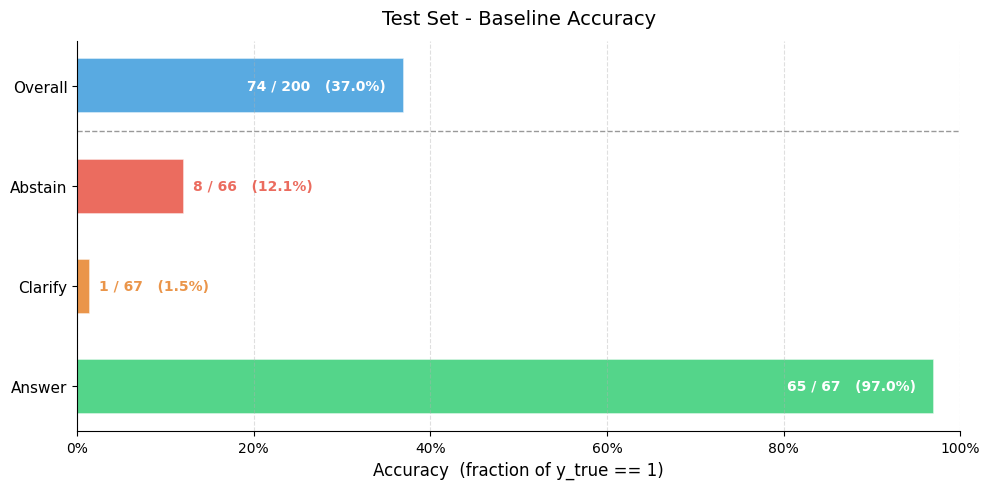

In [16]:
plot_baseline_accuracy(y_test, type_test, title="Test Set - Baseline Accuracy")

##### 2.&nbsp;Minimum Bayes Risk (Empirical Approach)

The Utility Risk Approach differs from the results presented in this section as while the Utility Risk Approach also utilizes minimum bayes risk, it goes on pure theoratical principles assuming that the model is well calibrated (which random forest was found to be so), on the otherhand, this section's approach utilizes validation data to derive the thresholds that actually attempt to gain the highest accuracy.

###### a.&nbsp;Training Set

Check how well the random forest model performs on data already seen.

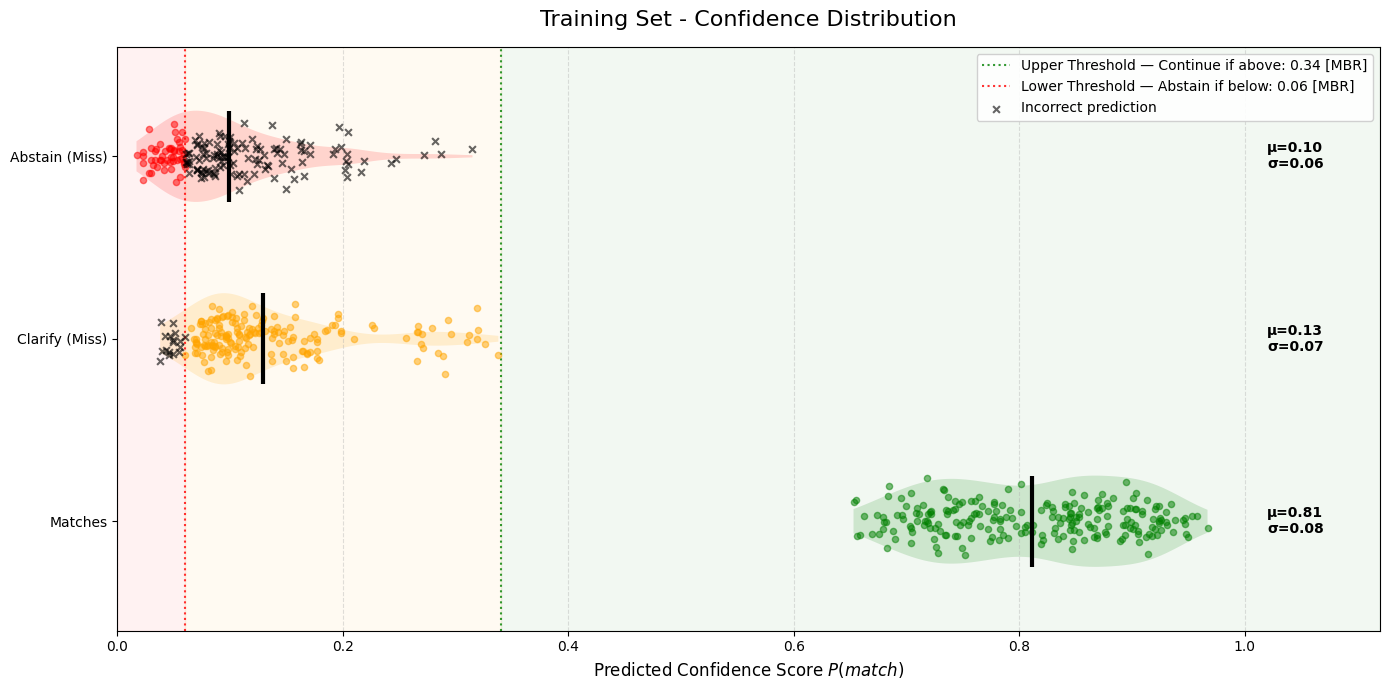

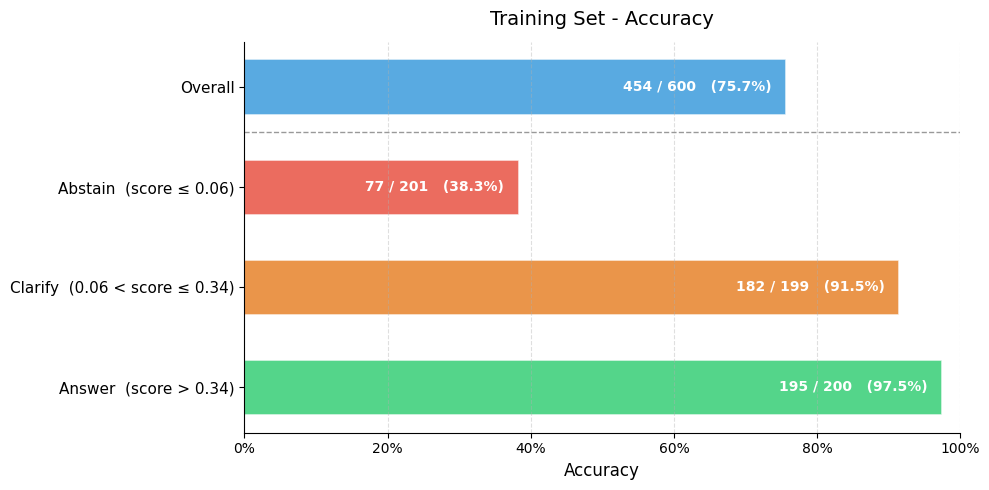

In [17]:
plot_confidence_distribution(y_train, p_hat_rf_train, type_train, title="Training Set")

###### b.&nbsp;Test Set

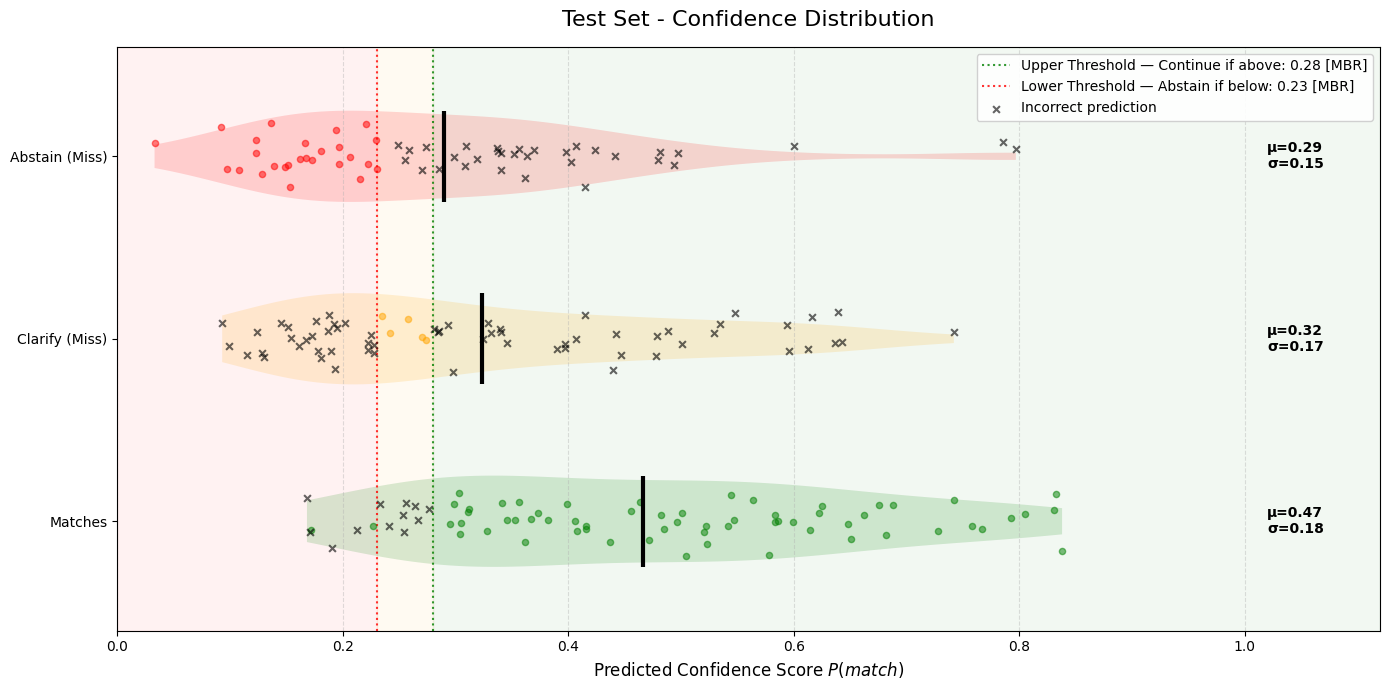

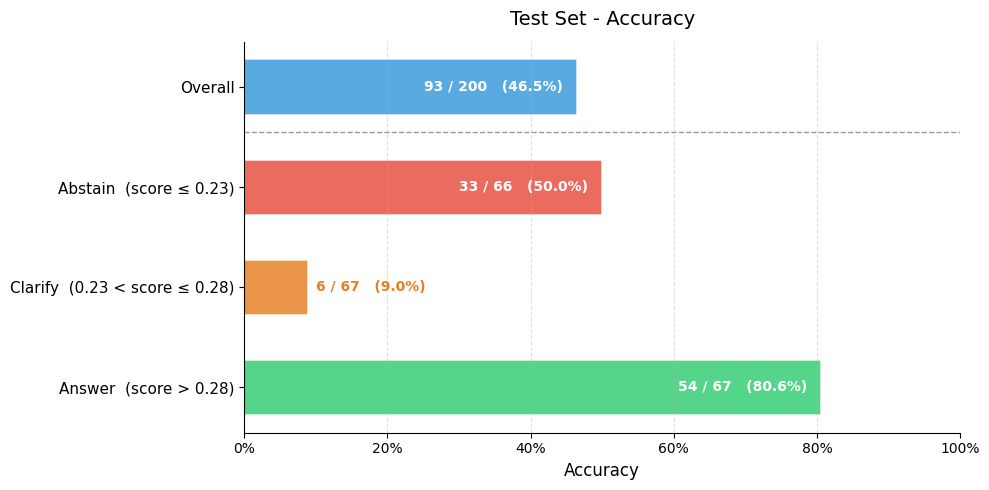

In [18]:
plot_confidence_distribution(y_test, p_hat_rf, type_test, title="Test Set", val_y_true=y_val, val_y_probs=p_hat_rf_val, val_types=type_val)

##### 3.&nbsp;Utility Risk (Theoretical Approach)

###### a.&nbsp;Low-Risk

Upper Threshold: 0.2500

Lower Threshold: 0.1999

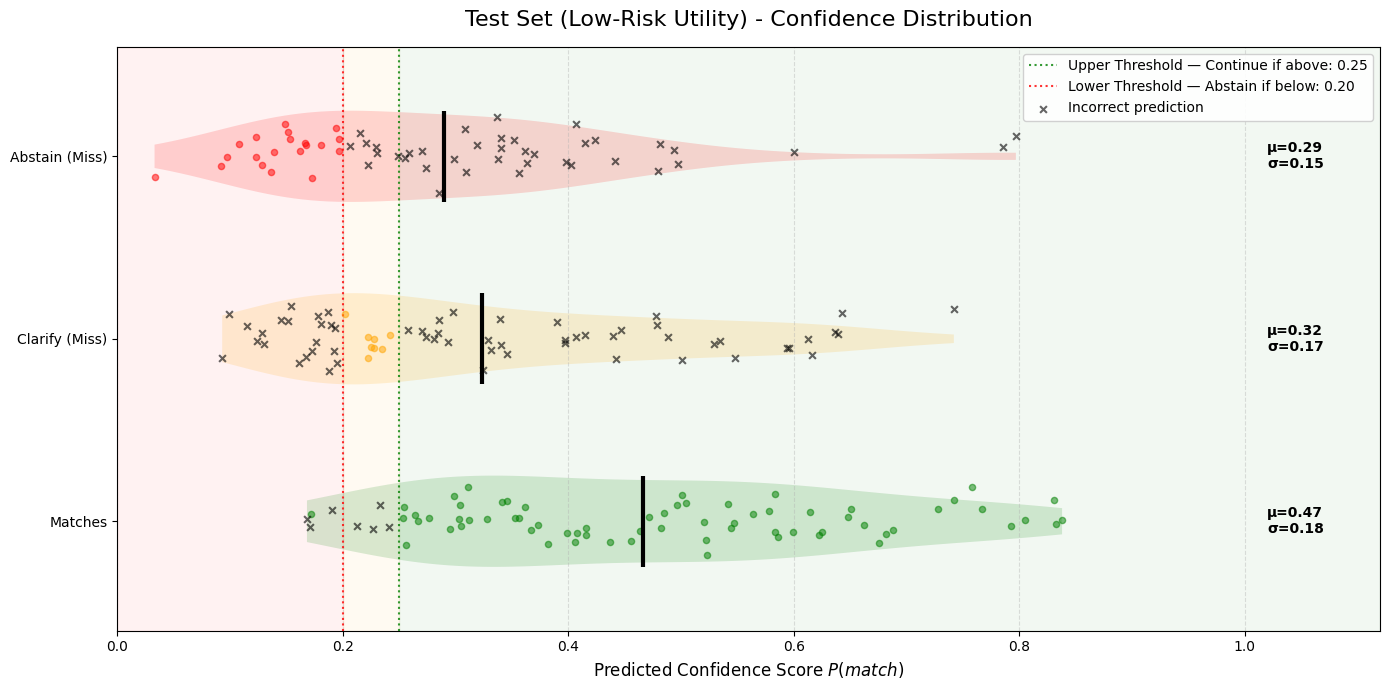

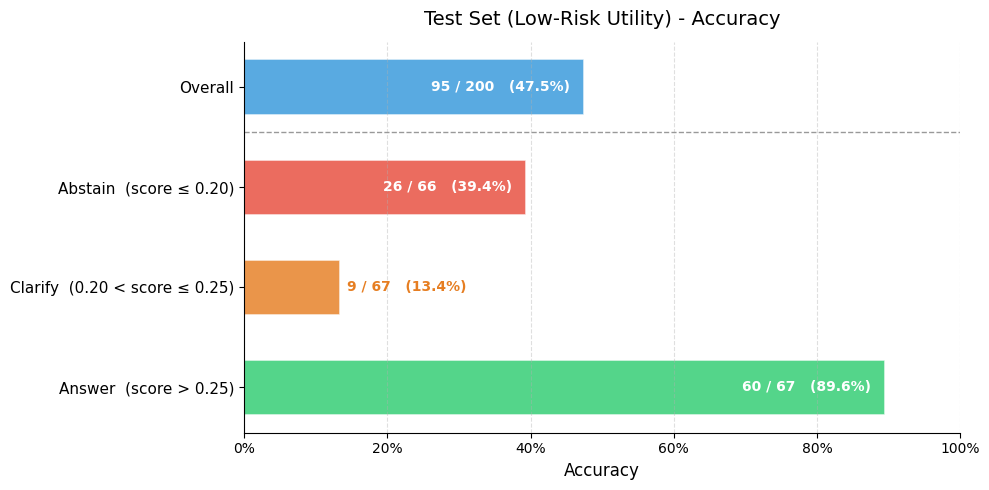

In [19]:
plot_confidence_distribution(y_test, p_hat_rf, type_test, title="Test Set (Low-Risk Utility)", a=0.2500, b=0.1999)

###### b.&nbsp;Medium-Risk

Upper Threshold: 0.4706

Lower Threshold: 0.1999

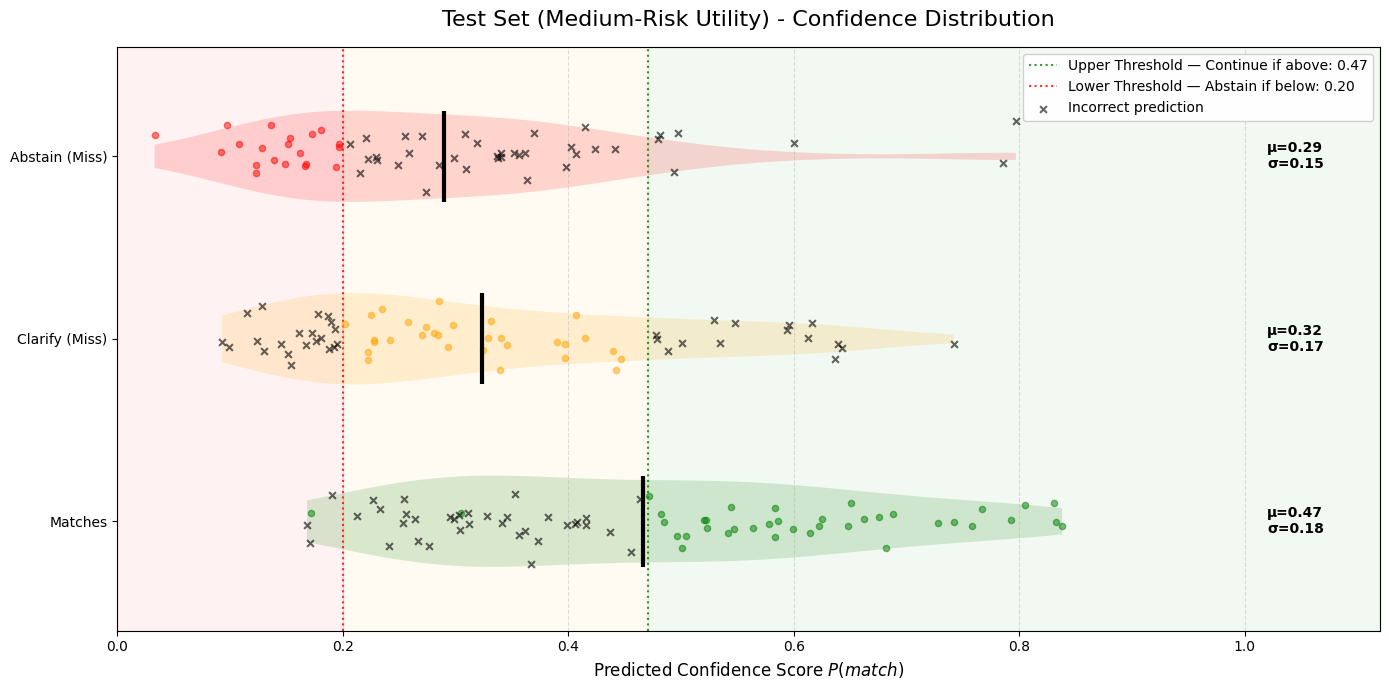

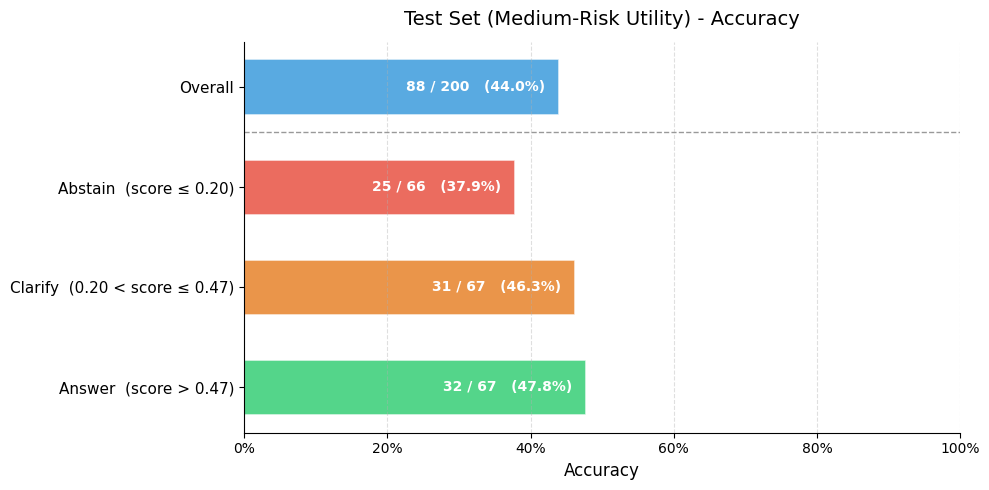

In [20]:
plot_confidence_distribution(y_test, p_hat_rf, type_test, title="Test Set (Medium-Risk Utility)", a=0.4706, b=0.1999)

###### c.&nbsp;High-Risk

Upper Threshold: 0.9073

Lower Threshold: 0.1999

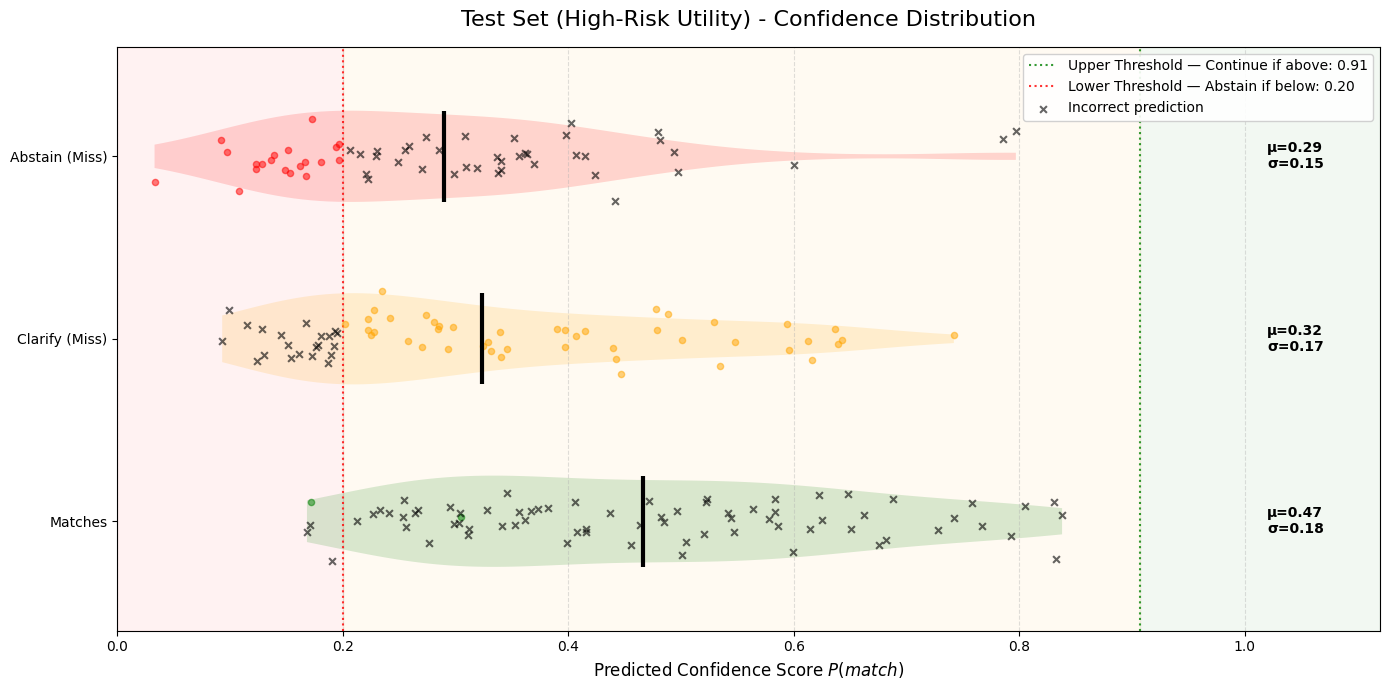

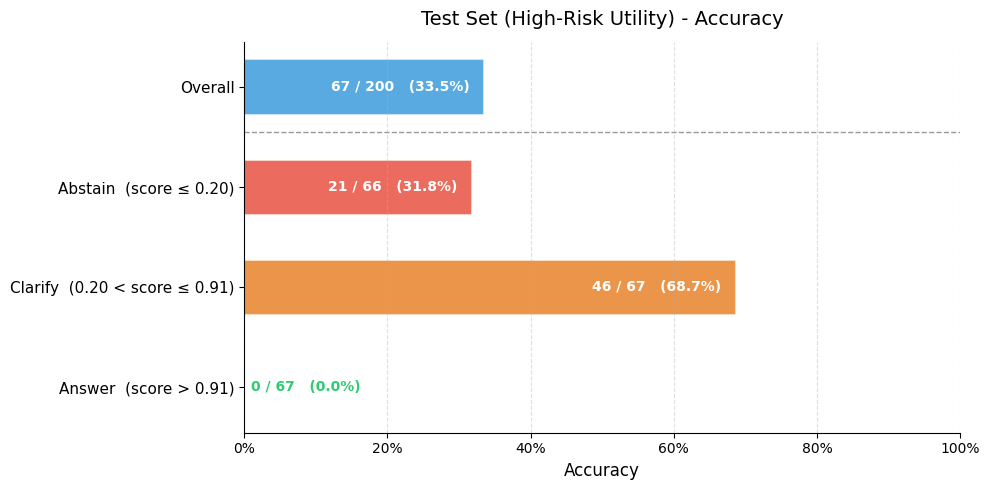

In [21]:
plot_confidence_distribution(y_test, p_hat_rf, type_test, title="Test Set (High-Risk Utility)", a=0.9073, b=0.1999)

##### 4.&nbsp;Alternative Approach

Instead of training random forest model to predict confidence and select action based on thresholds, can we train a random forest model to directly predict what action to execute (abstain/clarify/answer). Such approach disregards abstaining even if the model has high confidence and rather fully relies on model internal BERTScores to drive decisions.

###### a.&nbsp;Implementation

In [22]:
# Alternative Random Forest

def encode_type(arr):
    mapping = {
        'abstain': 0,
        'clarify': 1,
        'answer': 2
    }
    vectorized_map = np.vectorize(mapping.get)
    return vectorized_map(arr)
def decode_type(arr):
    inverse_mapping = {
        0: 'abstain',
        1: 'clarify',
        2: 'answer'
    }
    vectorized_decode = np.vectorize(inverse_mapping.get)
    return vectorized_decode(arr)

alternative_rf = RandomForestClassifier(
    n_estimators=1000, max_depth=20, max_features=10,
    random_state=42, n_jobs=-1)
alternative_rf.fit(X_train, encode_type(type_train))

p_hat_actions  = decode_type(alternative_rf.predict(X_test))

In [23]:
from matplotlib.lines import Line2D

def plot_confidence_distribution_by_type(
    true_types,
    pred_types,
    pred_confidence,
    y_true,
    title="Confidence Distribution by Type",
):
    true_types = np.asarray(true_types)
    pred_types = np.asarray(pred_types)
    pred_confidence = np.asarray(pred_confidence, dtype=float)
    y_true = np.asarray(y_true)

    if not (len(true_types) == len(pred_types) == len(pred_confidence) == len(y_true)):
        raise ValueError(
            "true_types, pred_types, pred_confidence, and y_true must have same length"
        )

    categories = [
        ('answer', 0, 'Answer type'),
        ('clarify', 1, 'Clarify type'),
        ('abstain', 2, 'Abstain type'),
    ]

    pred_colors = {
      'answer':  '#2ecc71',   # green
      'clarify': '#3498db',   # blue
      'abstain': '#e74c3c',   # red
    }

    fig, ax = plt.subplots(figsize=(14, 7))
    rng = np.random.default_rng(0)

    for true_t, y_level, label in categories:
        mask = (true_types == true_t)
        scores = pred_confidence[mask]

        if len(scores) == 0:
            continue

        preds = pred_types[mask]
        yt = y_true[mask]
        jitter = rng.normal(loc=y_level, scale=0.08, size=len(scores))

        # monotone violin background
        vp = ax.violinplot(
            scores,
            positions=[y_level],
            vert=False,
            widths=0.55,
            showmeans=False,
            showmedians=False,
            showextrema=False,
        )

        for body in vp['bodies']:
            body.set_facecolor('lightgray')
            body.set_alpha(0.35)
            body.set_edgecolor('gray')

        # plot by color
        for pred_t, color in pred_colors.items():
            pred_mask = (preds == pred_t)

            if not np.any(pred_mask):
                continue

            pos_mask = pred_mask & (yt == 1)
            ax.scatter(
                scores[pos_mask],
                jitter[pos_mask],
                s=30,
                marker='o',
                c=color,
                alpha=0.8,
                edgecolors='none',
                zorder=3,
            )

            neg_mask = pred_mask & (yt == 0)
            ax.scatter(
                scores[neg_mask],
                jitter[neg_mask],
                s=38,
                marker='x',
                c=color,
                alpha=0.9,
                linewidths=1.5,
                zorder=4,
            )

        # right-side summary stats text only
        mu = float(np.mean(scores))
        sigma = float(np.std(scores))

        ax.text(
            1.02,
            y_level,
            f'μ={mu:.2f}\nσ={sigma:.2f}',
            va='center',
            fontsize=10,
            fontweight='bold'
        )

    ax.set_title(title, fontsize=16, pad=14)
    ax.set_xlabel("Predicted confidence", fontsize=12)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(
        ['Answer type', 'Clarify type', 'Abstain type'],
        fontsize=11
    )
    ax.set_xlim(0, 1.12)
    ax.set_ylim(-0.6, 2.6)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

    # legend for marker shapes
    marker_legend = [
        Line2D([0], [0], marker='o', color='black',
               label='LLM judge = 1', linestyle='None', markersize=8),
        Line2D([0], [0], marker='x', color='black',
               label='LLM judge = 0', linestyle='None', markersize=8),
    ]

    # legend for colors
    color_legend = [
        Line2D([0], [0], marker='o', color='w',
               label='Pred: Answer',
               markerfacecolor=pred_colors['answer'], markersize=8),
        Line2D([0], [0], marker='o', color='w',
               label='Pred: Clarify',
               markerfacecolor=pred_colors['clarify'], markersize=8),
        Line2D([0], [0], marker='o', color='w',
               label='Pred: Abstain',
               markerfacecolor=pred_colors['abstain'], markersize=8),
    ]

    leg1 = ax.legend(
        handles=marker_legend,
        loc='upper right',
        framealpha=0.95,
        title="Marker (LLM judge)"
    )
    ax.add_artist(leg1)

    ax.legend(
        handles=color_legend,
        loc='upper center',
        framealpha=0.95,
        title="Color (predicted type)"
    )

    plt.tight_layout()
    plt.show()

###### b.&nbsp;Results

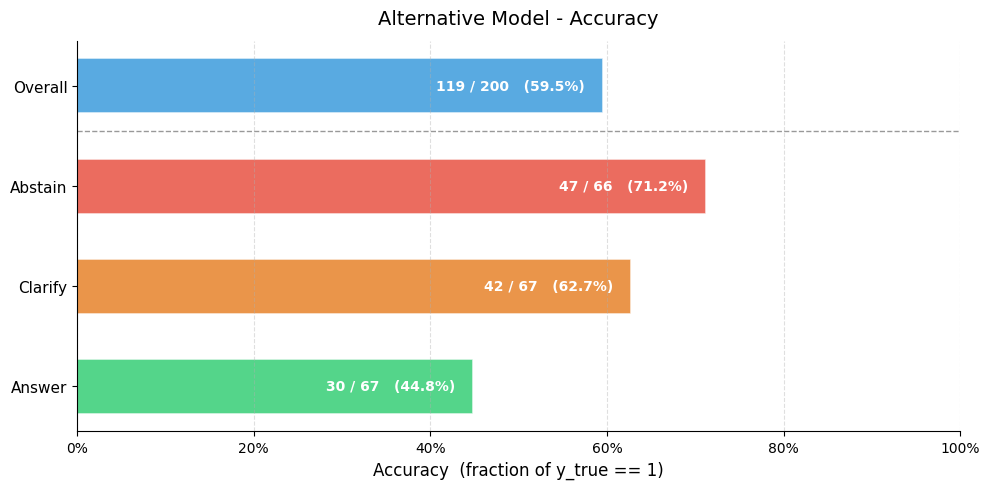

In [24]:
plot_type_prediction_accuracy(
    true_types=type_test,
    pred_types=p_hat_actions,
    title="Alternative Model - Accuracy"
)

The following confidence distribution is different from the previous confidence distributions as in this 'alternative' model, the predicted type doesn't take in thresholds and confidence scores, but rather directly predicts type from the layers' bertscores. Such plot is only generated to visually analyze the performance of the 'alternative' model with consideration of what the confidence score each data point would be at and to infer if there exists any correlation among the different confidence thresholding vs direct action prediction approaches.

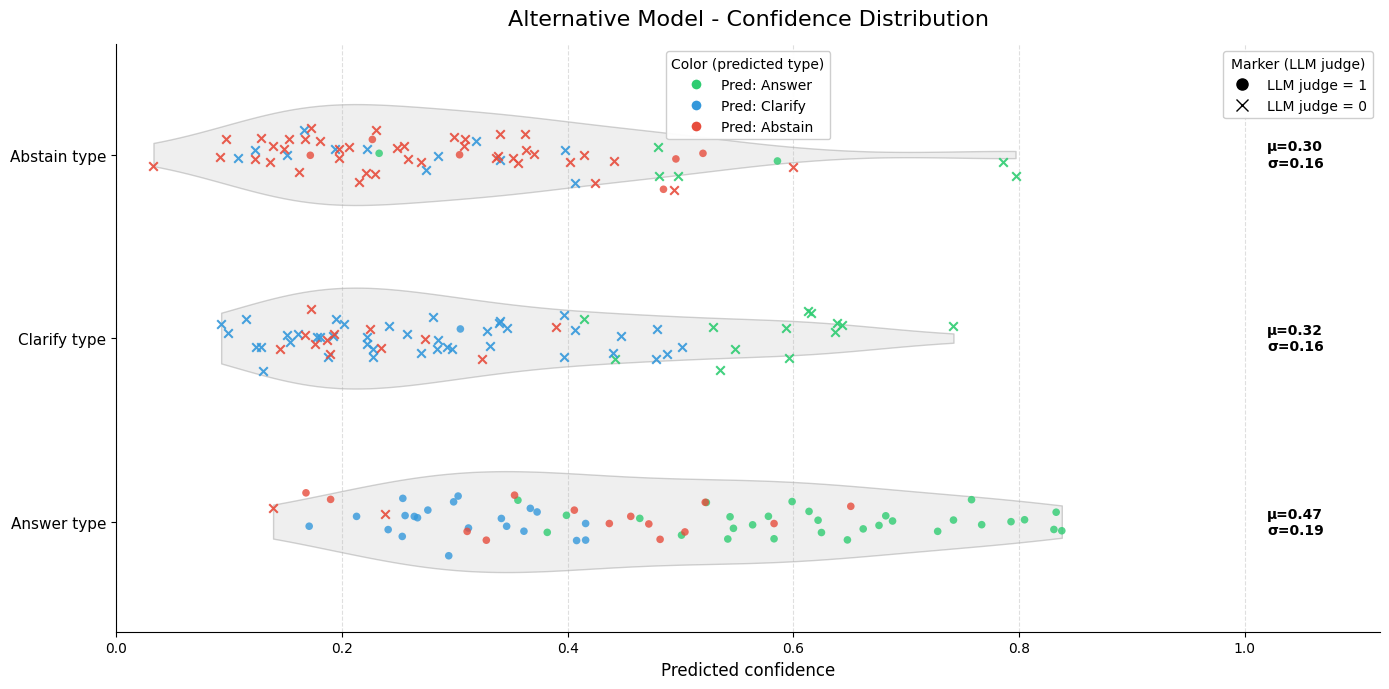

In [25]:
plot_confidence_distribution_by_type(
    true_types=type_test,
    pred_types=p_hat_actions,
    pred_confidence=p_hat_rf,
    y_true=y_test,
    title="Alternative Model - Confidence Distribution"
)